# 04 — Poisson NMF (mutations × samples) → 4 latent components


In [1]:

from pathlib import Path
import os, time, numpy as np, pandas as pd
from sklearn.decomposition import NMF
import matplotlib.pyplot as plt
from IPython.display import display

np.seterr(all="ignore")  # keep output clean

# Auto-detect repo root
cwd = Path().resolve()
repo_name = "oxbio-variant-forecasting"
while cwd.name != repo_name and cwd.parent != cwd:
    cwd = cwd.parent
REPO = cwd.as_posix()

PATH_SNV  = f"{REPO}/results/preprocessing/tables/feature_store_snv.csv"
PATH_JAHN = f"{REPO}/data/jahn_like.csv"
PATH_SIG  = f"{REPO}/results/preprocessing/tables/feature_store_signatures.csv"  # optional anchors
OUT_DIR   = f"{REPO}/results/eda/nnmf_poisson"
os.makedirs(OUT_DIR, exist_ok=True)

# Hyperparams
N_COMPONENTS = 4
RANDOM_STATE = 1234
MAX_ITER = 5000
CHECK_EVERY = 25
RENORM_EVERY = 50
TOL_REL = 1e-6
L2_W = 1e-4
L2_H = 1e-4
RESTARTS = 4
TOP_MUTS = 12
EPS = 1e-12

# Time limits
MAX_SECONDS_PER_RESTART = 60
GLOBAL_MAX_SECONDS = 240
PRINT_EVERY_SECS = 3.0

print("Auto-detected repo root:", REPO)
print("SNV path (primary):", PATH_SNV)
print("SNV path (fallback):", PATH_JAHN)
print("Signatures (optional):", PATH_SIG)
print("Output dir:", OUT_DIR)


Auto-detected repo root: C:/Users/osoom/OneDrive/Desktop/ssssssss/oxbio-variant-forecasting
SNV path (primary): C:/Users/osoom/OneDrive/Desktop/ssssssss/oxbio-variant-forecasting/results/preprocessing/tables/feature_store_snv.csv
SNV path (fallback): C:/Users/osoom/OneDrive/Desktop/ssssssss/oxbio-variant-forecasting/data/jahn_like.csv
Signatures (optional): C:/Users/osoom/OneDrive/Desktop/ssssssss/oxbio-variant-forecasting/results/preprocessing/tables/feature_store_signatures.csv
Output dir: C:/Users/osoom/OneDrive/Desktop/ssssssss/oxbio-variant-forecasting/results/eda/nnmf_poisson


In [2]:

# Data load & hygiene
if os.path.exists(PATH_SNV):
    df = pd.read_csv(PATH_SNV)
    src = PATH_SNV
elif os.path.exists(PATH_JAHN):
    df = pd.read_csv(PATH_JAHN)
    src = PATH_JAHN
else:
    raise FileNotFoundError("Neither feature_store_snv.csv nor jahn_like.csv found at paths.")

need = {"site_id","date","mutation","count","coverage"}
missing = need - set(df.columns)
if missing:
    raise ValueError(f"Counts file missing columns: {missing}")

df["site_id"] = df["site_id"].astype(str)
df["mutation"] = df["mutation"].astype(str)
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date"]).copy()

df["count"] = pd.to_numeric(df["count"], errors="coerce").fillna(0).astype(int).clip(lower=0)
df["coverage"] = pd.to_numeric(df["coverage"], errors="coerce").fillna(0).astype(int)
df.loc[df["count"] > df["coverage"], "count"] = df["coverage"]

if "sample_id" not in df.columns:
    df["sample_id"] = df["site_id"].astype(str) + "::" + df["date"].dt.date.astype(str)

print("Loaded:", src, "rows:", len(df))
try:
    display(df.head())
except Exception:
    print(df.head())


Loaded: C:/Users/osoom/OneDrive/Desktop/ssssssss/oxbio-variant-forecasting/results/preprocessing/tables/feature_store_snv.csv rows: 82538


,site_id,date,sample_id,mutation,count,coverage,af,af_obs,af_censored,lod_threshold
0,BE - Laupen - ARA Sensetal,2021-02-01,ERR9862687,AA:E:P71L,0,1194,0.000000,0.000000,False,0.01
1,BE - Laupen - ARA Sensetal,2021-02-01,ERR9862687,AA:M:I82T,9,35046,0.000257,0.000257,False,0.01
2,BE - Laupen - ARA Sensetal,2021-02-01,ERR9862687,AA:N:D377Y,5,1473,0.003394,0.003394,False,0.01
3,BE - Laupen - ARA Sensetal,2021-02-01,ERR9862687,AA:N:D3L,0,263877,0.000000,0.000000,False,0.01
4,BE - Laupen - ARA Sensetal,2021-02-01,ERR9862687,AA:N:D63G,29,370990,0.000078,0.000078,False,0.01


In [3]:

# Build matrix X (samples × mutations, counts) — use float32 for speed
tbl = (df.groupby(["sample_id","site_id","date","mutation"], as_index=False)["count"].sum())

X_df = tbl.pivot(index="sample_id", columns="mutation", values="count").fillna(0.0).astype("float32")

sample_meta = (
    tbl.drop_duplicates(subset=["sample_id"])[["sample_id","site_id","date"]]
       .set_index("sample_id")
       .reindex(X_df.index)
       .reset_index()
)

print("Matrix shape (samples × mutations):", X_df.shape)
try:
    display(X_df.iloc[:5, :8])
except Exception:
    print(X_df.iloc[:5, :8])


Matrix shape (samples × mutations): (1575, 62)


mutation,AA:E:P71L,AA:M:I82T,AA:N:D377Y,AA:N:D3L,AA:N:D63G,AA:N:P80R,AA:N:R203M,AA:N:S235F
sample_id,,,,,,,,
ERR5922169,0.0,7.0,0.0,0.0,3178.0,62.0,1.0,256.0
ERR5922198,1.0,2.0,0.0,0.0,7.0,7.0,0.0,193.0
ERR5922199,1.0,4.0,0.0,0.0,6.0,2.0,0.0,79.0
ERR5922200,2.0,0.0,0.0,0.0,5.0,4.0,0.0,249.0
ERR5922201,2.0,2.0,1.0,0.0,1.0,4.0,0.0,127.0


In [4]:

# Helpers
def gkl_with_WH(A, WH, eps=EPS):
    A = A.astype("float64") + eps
    WH = WH.astype("float64") + eps
    val = A * np.log(A / WH) - A + WH
    val[~np.isfinite(val)] = 0.0
    return float(np.sum(val))

def poisson_nmf_mu_timed(
    X, K, W0=None, H0=None, max_iter=5000, tol_rel=1e-6,
    check_every=25, renorm_every=50, l2_W=1e-4, l2_H=1e-4,
    max_seconds=None, print_header="", print_every_secs=3.0, seed=1234
):
    """
    KL (Poisson) NMF with Lee-Seung multiplicative updates plus mild L2 and time cap.
    Returns (W, H, best_loss, iters_done).
    """
    rng = np.random.default_rng(seed)
    n, m = X.shape
    W = np.maximum(W0 if W0 is not None else rng.random((n, K), dtype="float32"), EPS).astype("float32")
    H = np.maximum(H0 if H0 is not None else rng.random((K, m), dtype="float32"), EPS).astype("float32")

    start = time.time()
    last_print = start
    prev_loss = np.inf
    best_loss = np.inf
    best_W = W.copy()
    best_H = H.copy()
    patience = 0
    PATIENCE_MAX = 5

    for it in range(1, max_iter + 1):
        WH = (W @ H).astype("float32") + EPS
        R = (X / WH).astype("float32")

        # Update H
        num_H = (W.T @ R).astype("float32")
        den_H = (W.sum(axis=0)[:, None]).astype("float32")
        H *= num_H / np.maximum(den_H + l2_H * H, EPS).astype("float32")
        H = np.maximum(H, EPS)

        # Update W
        WH = (W @ H).astype("float32") + EPS
        R = (X / WH).astype("float32")
        num_W = (R @ H.T).astype("float32")
        den_W = (H.sum(axis=1)[None, :]).astype("float32")
        W *= num_W / np.maximum(den_W + l2_W * W, EPS).astype("float32")
        W = np.maximum(W, EPS)

        # Renormalize H rows to L1=1 and push scale into W
        if (it % renorm_every) == 0:
            s = H.sum(axis=1, keepdims=True).astype("float32")
            s = np.maximum(s, EPS).astype("float32")
            H /= s
            W *= s.T

        now = time.time()
        # Periodic checks
        if (it % check_every) == 0:
            WH = (W @ H).astype("float32") + EPS
            loss = gkl_with_WH(X, WH)
            if loss < best_loss:
                best_loss = loss
                best_W = W.copy()
                best_H = H.copy()

            # Relative improvement check
            if np.isfinite(prev_loss) and prev_loss > 0:
                rel_impr = (prev_loss - loss) / prev_loss
                patience = patience + 1 if rel_impr < tol_rel else 0
                if patience >= PATIENCE_MAX:
                    if print_header:
                        print(f"{print_header} early-stop: rel_impr<{tol_rel} for {PATIENCE_MAX} checks @ iter {it}, loss={loss:,.2f}")
                    return best_W, best_H, best_loss, it
            prev_loss = loss

            # Progress print
            if print_header and (now - last_print) >= print_every_secs:
                print(f"{print_header} iter={it:,}  KL={loss:,.2f}  elapsed={now-start:.1f}s")
                last_print = now

        # Time cap
        if max_seconds is not None and (now - start) >= max_seconds:
            if print_header:
                print(f"{print_header} time cap hit @ iter {it}, best_KL={best_loss:,.2f}, elapsed={now-start:.1f}s")
            return best_W, best_H, best_loss, it

    return best_W, best_H, best_loss, max_iter

def build_anchor_H0(sig_path, kept_cols, K, seed=RANDOM_STATE):
    if not os.path.exists(sig_path):
        return None
    try:
        sig = pd.read_csv(sig_path)
        if "mutation" not in sig.columns:
            return None
        group_col = None
        for c in ["lineage","signature","label","component","comp","group"]:
            if c in sig.columns:
                group_col = c
                break
        if group_col is None:
            return None
        kept_cols = list(kept_cols)
        sig = sig[sig["mutation"].isin(kept_cols)]
        groups = sig[group_col].value_counts().index.tolist()[:K]
        if len(groups) < K:
            return None
        m_index = {m: j for j, m in enumerate(kept_cols)}
        H0 = np.full((K, len(kept_cols)), 0.0, dtype="float32")
        for k, g in enumerate(groups):
            muts = sig.loc[sig[group_col] == g, "mutation"].unique().tolist()
            idx = [m_index[m] for m in muts if m in m_index]
            if len(idx) > 0:
                H0[k, idx] = 1.0
        rng = np.random.default_rng(seed)
        for k in range(K):
            if H0[k].sum() <= 0:
                v = rng.random(len(kept_cols)).astype("float32") + 1e-6
                v /= v.sum()
                H0[k] = v
        H0 /= np.maximum(H0.sum(axis=1, keepdims=True), 1e-6)
        return H0.astype("float32")
    except Exception as e:
        print("[warn] anchor build failed:", e)
        return None


In [5]:

# Reduce X by removing empty rows/cols (reinsert later)
X_full = X_df.values.astype("float32")
rows_mask = (X_full.sum(axis=1) > 0)
cols_mask = (X_full.sum(axis=0) > 0)
X = X_full[rows_mask][:, cols_mask]
kept_cols = np.array(X_df.columns)[cols_mask]

if X.size == 0:
    raise ValueError("All-zero matrix after filtering; nothing to factorize.")

print(f"Reduced matrix: {X.shape} (dropped rows={(~rows_mask).sum()}, cols={(~cols_mask).sum()})")

H0_anchor = build_anchor_H0(PATH_SIG, kept_cols, N_COMPONENTS, seed=RANDOM_STATE)
if H0_anchor is not None:
    print("[anchors] Built H0 from signatures on reduced columns:", H0_anchor.shape)
else:
    print("[anchors] None available; proceeding with NNDSVDAR/random inits.")


Reduced matrix: (1575, 59) (dropped rows=0, cols=3)
[anchors] Built H0 from signatures on reduced columns: (4, 59)


In [6]:

# Multiple restarts (best KL picked) — time-bounded with progress
K = N_COMPONENTS
best = {"loss": np.inf, "W": None, "H": None, "iters": 0, "tag": ""}
seeds = [RANDOM_STATE + i for i in range(RESTARTS)]
global_start = time.time()

# A) NNDSVDAR warm-starts
seeds_for_sk = seeds[:max(1, RESTARTS // 2)]
for ridx, s in enumerate(seeds_for_sk, 1):
    if (time.time() - global_start) > GLOBAL_MAX_SECONDS: break
    print(f"[restart A {ridx}/{len(seeds_for_sk)}] NNDSVDAR seed={s}")
    nmf_init = NMF(
        n_components=K,
        init="nndsvdar",
        solver="mu",
        beta_loss="kullback-leibler",
        max_iter=50,
        tol=0,
        random_state=s,
    )
    W0 = nmf_init.fit_transform(X + EPS)
    H0 = nmf_init.components_
    Wc, Hc, loss, iters = poisson_nmf_mu_timed(
        X, K, W0=W0, H0=H0, max_iter=MAX_ITER, tol_rel=TOL_REL,
        check_every=CHECK_EVERY, renorm_every=RENORM_EVERY,
        l2_W=L2_W, l2_H=L2_H,
        max_seconds=MAX_SECONDS_PER_RESTART,
        print_header=f"  [seed {s}]",
        print_every_secs=PRINT_EVERY_SECS,
        seed=s
    )
    if loss < best["loss"]:
        best.update({"loss": loss, "W": Wc, "H": Hc, "iters": iters, "tag": f"nndsvdar(seed={s})"})

# B) Random seeds
rng = np.random.default_rng(RANDOM_STATE)
for ridx, s in enumerate(seeds, 1):
    if (time.time() - global_start) > GLOBAL_MAX_SECONDS: break
    print(f"[restart B {ridx}/{len(seeds)}] random seed={s}")
    W0 = rng.random((X.shape[0], K), dtype="float32") + 1e-6
    H0 = rng.random((K, X.shape[1]), dtype="float32") + 1e-6
    H0 /= np.maximum(H0.sum(axis=1, keepdims=True), 1e-6)
    Wc, Hc, loss, iters = poisson_nmf_mu_timed(
        X, K, W0=W0, H0=H0, max_iter=MAX_ITER, tol_rel=TOL_REL,
        check_every=CHECK_EVERY, renorm_every=RENORM_EVERY,
        l2_W=L2_W, l2_H=L2_H,
        max_seconds=MAX_SECONDS_PER_RESTART,
        print_header=f"  [seed {s}]",
        print_every_secs=PRINT_EVERY_SECS,
        seed=s
    )
    if loss < best["loss"]:
        best.update({"loss": loss, "W": Wc, "H": Hc, "iters": iters, "tag": f"random(seed={s})"})

# C) Anchors (if available)
if (time.time() - global_start) <= GLOBAL_MAX_SECONDS and H0_anchor is not None:
    print("[restart C] anchors")
    try:
        Wc, Hc, loss, iters = poisson_nmf_mu_timed(
            X, K, W0=None, H0=H0_anchor, max_iter=MAX_ITER, tol_rel=TOL_REL,
            check_every=CHECK_EVERY, renorm_every=RENORM_EVERY,
            l2_W=L2_W, l2_H=L2_H,
            max_seconds=MAX_SECONDS_PER_RESTART,
            print_header="  [anchors]",
            print_every_secs=PRINT_EVERY_SECS,
            seed=RANDOM_STATE
        )
        if loss < best["loss"]:
            best.update({"loss": loss, "W": Wc, "H": Hc, "iters": iters, "tag": "anchors"})
    except Exception as e:
        print("[warn] anchor run skipped:", e)

print(f"[best] KL={best['loss']:,.2f}  iters={best['iters']}  init={best['tag']}  total_elapsed={time.time()-global_start:.1f}s")


[restart A 1/2] NNDSVDAR seed=1234
  [seed 1234] iter=2,775  KL=96,943,052.87  elapsed=3.0s
[restart A 2/2] NNDSVDAR seed=1235
  [seed 1235] iter=2,500  KL=96,862,072.91  elapsed=3.0s
  [seed 1235] iter=4,275  KL=96,943,053.25  elapsed=6.0s
[restart B 1/4] random seed=1234
  [seed 1234] iter=2,825  KL=102,791,367.94  elapsed=3.0s
[restart B 2/4] random seed=1235
  [seed 1235] iter=2,650  KL=96,748,473.33  elapsed=3.0s
[restart B 3/4] random seed=1236
  [seed 1236] iter=2,650  KL=100,191,993.86  elapsed=3.0s
[restart B 4/4] random seed=1237
  [seed 1237] iter=2,725  KL=96,818,165.28  elapsed=3.0s
[restart C] anchors
  [anchors] iter=2,525  KL=161,945,212.05  elapsed=3.0s
[best] KL=96,735,254.16  iters=5000  init=random(seed=1237)  total_elapsed=40.8s


In [7]:

# Reinsert dropped rows/cols back to full shape and compute metrics
W_red, H_red = best["W"], best["H"]
if W_red is None or H_red is None:
    raise RuntimeError("No valid factorization was produced. Try reducing RESTARTS or increasing TOL_REL.")

W_full = np.zeros((X_full.shape[0], K), dtype="float32")
H_full = np.zeros((K, X_full.shape[1]), dtype="float32")
W_full[rows_mask, :] = W_red
H_full[:, cols_mask] = H_red

# Final normalization: make H rows sum to 1 (profiles)
row_sums = H_full.sum(axis=1, keepdims=True)
row_sums = np.maximum(row_sums, 1e-6).astype("float32")
H_full = (H_full / row_sums).astype("float32")
W_full = (W_full * row_sums.T).astype("float32")

# Metrics vs baseline (on full matrix)
def _gkl(A, B):
    A = A.astype("float64") + 1e-12
    B = B.astype("float64") + 1e-12
    val = A * np.log(A / B) - A + B
    val[~np.isfinite(val)] = 0.0
    return float(np.sum(val))

X_hat_full = (W_full @ H_full).astype("float32") + 1e-12
gkl_model = _gkl(X_full, X_hat_full)
mu = np.mean(X_full + 1e-12, axis=0, keepdims=True).astype("float32")
X0 = np.repeat(mu, X_full.shape[0], axis=0).astype("float32")
gkl_base = _gkl(X_full, X0)
explained = 1.0 - (gkl_model / max(gkl_base, 1e-12))

print(f"GKL (model): {gkl_model:,.2f}")
print(f"GKL (baseline): {gkl_base:,.2f}")
print(f"Deviance explained (vs baseline): {explained*100:.2f}%")

# Save outputs
comp_cols = [f"Comp {i+1}" for i in range(K)]

# W (samples)
W_df = (
    pd.DataFrame(W_full, index=X_df.index, columns=comp_cols)
      .reset_index()
      .rename(columns={"index": "sample_id"})
      .merge(sample_meta, on="sample_id", how="left")
)[["sample_id", "site_id", "date"] + comp_cols]
W_df.to_csv(os.path.join(OUT_DIR, "W_samples.csv"), index=False)

# H (mutations)
H_df = (
    pd.DataFrame(H_full, index=comp_cols, columns=X_df.columns)
      .T.reset_index().rename(columns={"index": "mutation"})
)
H_df.to_csv(os.path.join(OUT_DIR, "H_mutations.csv"), index=False)

# H normalized by component (rows already sum to 1) — mirror prior filename
H_prop_df = H_df.copy()
H_prop_df.to_csv(os.path.join(OUT_DIR, "H_profiles_normalized.csv"), index=False)

# Top mutations per component
rows_out = []
for i, c in enumerate(comp_cols):
    ser = pd.Series(H_full[i, :], index=X_df.columns).sort_values(ascending=False).head(TOP_MUTS)
    for r, (mut, val) in enumerate(ser.items(), start=1):
        rows_out.append({"component": c, "rank": r, "mutation": mut, "loading": float(val)})
topk_df = pd.DataFrame(rows_out)
topk_df.to_csv(os.path.join(OUT_DIR, "top_mutations_per_component.csv"), index=False)

# Fit metrics summary
import time as _time
metrics_df = pd.DataFrame(
    [{
        "n_samples": int(X_full.shape[0]),
        "n_mutations": int(X_full.shape[1]),
        "components": int(K),
        "gkl_model": float(gkl_model),
        "gkl_baseline": float(gkl_base),
        "deviance_explained": float(explained),
        "max_iter_mu": MAX_ITER,
        "tol_rel": TOL_REL,
        "l2_W": L2_W,
        "l2_H": L2_H,
        "best_init": best["tag"],
        "iters_used": int(best["iters"]),
        "restarts": RESTARTS,
        "max_seconds_per_restart": MAX_SECONDS_PER_RESTART,
        "global_max_seconds": GLOBAL_MAX_SECONDS,
        "finished_at": _time.strftime("%Y-%m-%d %H:%M:%S")
    }]
)
metrics_df.to_csv(os.path.join(OUT_DIR, "fit_metrics.csv"), index=False)

print("Saved CSVs:")
print(" - W_samples.csv")
print(" - H_mutations.csv")
print(" - H_profiles_normalized.csv")
print(" - top_mutations_per_component.csv")
print(" - fit_metrics.csv")


GKL (model): 96,735,253.96
GKL (baseline): 849,099,116.66
Deviance explained (vs baseline): 88.61%
Saved CSVs:
 - W_samples.csv
 - H_mutations.csv
 - H_profiles_normalized.csv
 - top_mutations_per_component.csv
 - fit_metrics.csv


[ok] Loaded W: (1575, 7), H: (62, 5), topk: (48, 4)


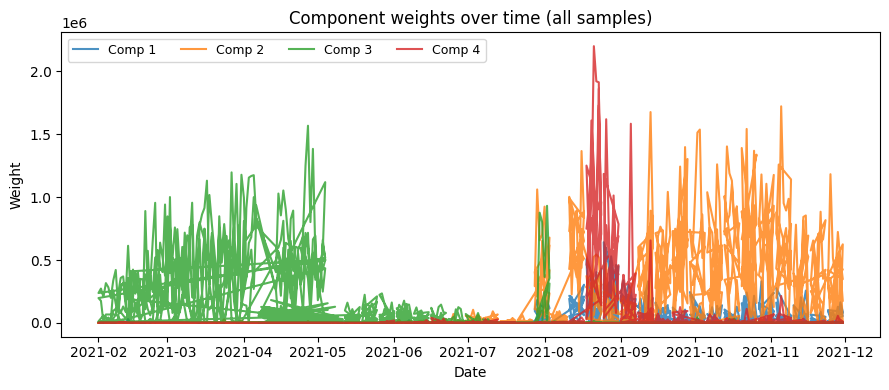

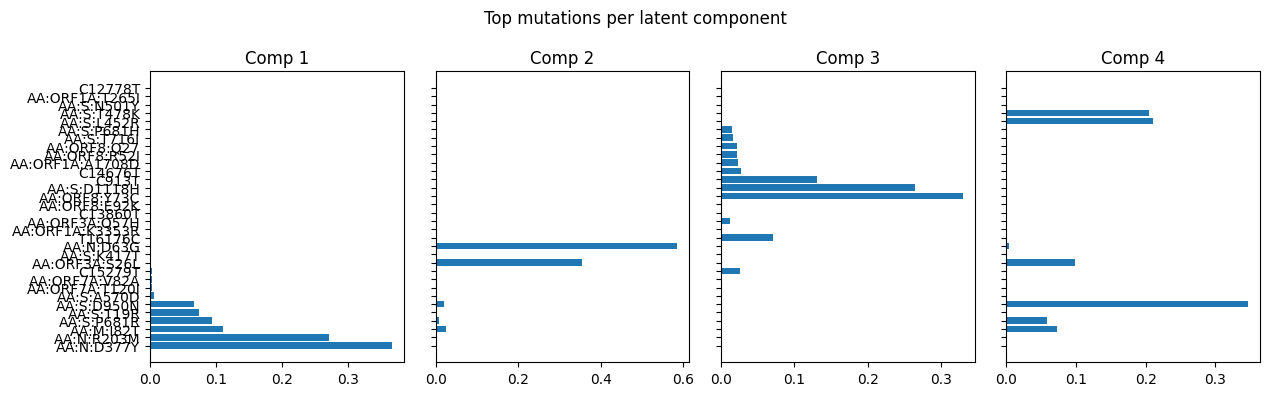

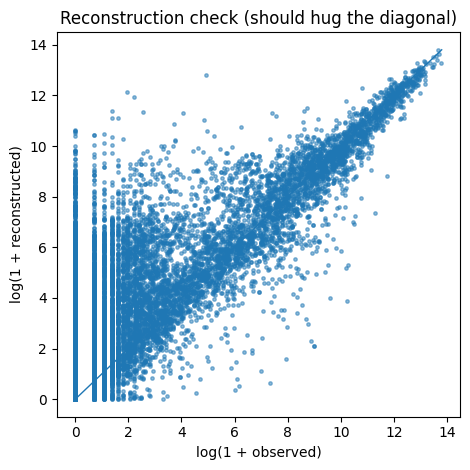

In [8]:

# Quick visualization — component overview
try:
    W_PATH = os.path.join(OUT_DIR, "W_samples.csv")
    H_PATH = os.path.join(OUT_DIR, "H_mutations.csv")
    TOPK_PATH = os.path.join(OUT_DIR, "top_mutations_per_component.csv")

    Wd = pd.read_csv(W_PATH, parse_dates=["date"])
    Hm = pd.read_csv(H_PATH)  # columns: mutation, Comp 1..K
    topk = pd.read_csv(TOPK_PATH)

    print(f"[ok] Loaded W: {Wd.shape}, H: {Hm.shape}, topk: {topk.shape}")

    comp_cols = [c for c in Wd.columns if c.startswith("Comp")]

    # Plot 1: component weights across time
    fig, ax = plt.subplots(figsize=(9, 4))
    for c in comp_cols:
        ax.plot(Wd["date"], Wd[c], label=c, alpha=0.8)
    ax.set_title("Component weights over time (all samples)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Weight")
    ax.legend(ncol=min(len(comp_cols), 4), fontsize=9)
    plt.tight_layout()
    plt.show()

    # Plot 2: top mutations per component
    fig, axs = plt.subplots(1, len(comp_cols), figsize=(3.2 * len(comp_cols), 4), sharey=True)
    for i, c in enumerate(sorted(topk["component"].unique(), key=lambda x: int(x.split()[-1]))):
        sub = topk[topk["component"] == c].sort_values("rank")
        axs[i].barh(sub["mutation"], sub["loading"])
        axs[i].invert_yaxis()
        axs[i].set_title(c)
    plt.suptitle("Top mutations per latent component")
    plt.tight_layout()
    plt.show()

    # Plot 3: reconstruction sanity — log scatter
    Wm = Wd[comp_cols].values.astype("float32")  # (n_samples, K)
    Hm_mat = Hm[comp_cols].values.astype("float32")  # (n_mutations, K)
    Xhat = Wm @ Hm_mat.T  # (n_samples, n_mutations)
    mut_order = Hm["mutation"].tolist()
    X_obs = X_df.reindex(columns=mut_order).values.astype("float32")

    rng = np.random.default_rng(RANDOM_STATE)
    idx_rows = rng.choice(X_obs.shape[0], size=min(300, X_obs.shape[0]), replace=False)
    idx_cols = rng.choice(X_obs.shape[1], size=min(300, X_obs.shape[1]), replace=False)
    A = np.log1p(X_obs[np.ix_(idx_rows, idx_cols)])
    B = np.log1p(Xhat[np.ix_(idx_rows, idx_cols)])

    fig, ax = plt.subplots(figsize=(4.8, 4.8))
    ax.scatter(A.ravel(), B.ravel(), s=6, alpha=0.5)
    lo = float(min(A.min(), B.min()))
    hi = float(max(A.max(), B.max()))
    ax.plot([lo, hi], [lo, hi], lw=1)
    ax.set_xlabel("log(1 + observed)")
    ax.set_ylabel("log(1 + reconstructed)")
    ax.set_title("Reconstruction check (should hug the diagonal)")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("[warn] plotting skipped:", e)
